## T02 - Greeks

#### Simulación de Procesos Financieros

José Armando Melchor Soto
 | 21/09/2026

---

### Libraries 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

---

### Functions

In [22]:
def data():
    """
    Creates a DataFrame containing the prices, volatilities,
    and remaining time for each month.

    Returns
    -------
    pd.DataFrame
        DataFrame containing the option data for each month.
    """
    df = {
        "Mes": ["Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre"],
        "Precio": [100, 102, 101, 105, 103, 110],
        "Volatilidad": [0.20, 0.25, 0.30, 0.28, 0.22, 0.20],
        "Tiempo_restante": [6/12, 5/12, 4/12, 3/12, 2/12, 1/12],
        "Meses_transcurridos": [0, 1, 2, 3, 4, 5]
    }
    return pd.DataFrame(df)


def cambios(df, S0, sigma0):
    """
    Calculates the changes in the stock price and volatility
    relative to their initial values.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the simulation data.
    S0 : float
        Initial stock price.
    sigma0 : float
        Initial volatility.

    Returns
    -------
    pd.DataFrame
        DataFrame with the dS and dsigma columns added.
    """
    df = df.copy()
    df["dS"] = df["Precio"] - S0
    df["dsigma"] = df["Volatilidad"] - sigma0
    return df


def greeks(V0, delta, gamma, vega, theta, dS, dsigma, mt):
    """
    Calculates the approximate option value using the Greeks.

    Parameters
    ----------
    V0 : float
        Initial option value.
    delta : float
        Sensitivity of the option value to changes in the stock price.
    gamma : float
        Sensitivity of Delta to changes in the stock price.
    vega : float
        Sensitivity of the option value to changes in volatility.
    theta : float
        Sensitivity of the option value to the passage of time.
    dS : float
        Change in the stock price.
    dsigma : float
        Change in volatility.
    mt : int
        Number of months elapsed since the initial date.

    Returns
    -------
    float
        Approximate option value calculated using the Greeks.
    """
    dt = mt / 12
    return V0 + delta*dS + 0.5*gamma*dS**2 + vega*dsigma + theta*dt


def black_scholes_call(S0, K, r, sigma, T):
    """
    Calculates the value of a European call option using
    the Black-Scholes model.

    Parameters
    ----------
    S0 : float
        Current stock price.
    K : float
        Strike price.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity in years.

    Returns
    -------
    float
        Black-Scholes value of the call option.
    """
    d1 = (np.log(S0/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S0*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)


def monte_carlo_call(S, K, r, sigma, T, n_simulations, seed=42):
    """
    Estimates the value of a European call option using
    Monte Carlo simulation.

    Parameters
    ----------
    S : float
        Current stock price.
    K : float
        Strike price.
    r : float
        Risk-free interest rate.
    sigma : float
        Volatility of the underlying asset.
    T : float
        Time to maturity in years.
    n_simulations : int
        Number of simulated scenarios.
    seed : int, optional
        Random seed used to make the results reproducible.

    Returns
    -------
    float
        Estimated value of the call option.
    """
    np.random.seed(seed)
    Z = np.random.standard_normal(n_simulations)
    ST = S*np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r*T)*np.mean(payoff)


def opcionvstiempo(df):
    """
    Plots and compares the option values calculated using
    the Greeks and the Black-Scholes model.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the calculated option values.

    Returns
    -------
    None
        Displays the comparison plot.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(df["Mes"], df["Greeks"], marker="o", label="Valor con Greeks", color="blue")
    plt.plot(df["Mes"], df["Black-Scholes"], marker="o", label="Black-Scholes", color="red")
    plt.xlabel("Mes")
    plt.ylabel("Valor de la opción")
    plt.title("Valor de la opción vs Tiempo")
    plt.legend()
    plt.grid(True)
    plt.show()


---

### Parte 1 : Observación

| Opción |    S |    K |    T | Prima | Delta | Vega | Theta |
| ------ | ---: | ---: | ---: | ----: | ----: | ---: | ----: |
| A      | $100 |  $90 | 1/12 |   $12 |  0.85 | 0.05 | -0.10 |
| B      | $100 | $100 | 3/12 |    $8 |  0.50 | 0.25 | -0.03 |
| C      | $100 | $120 |    1 |    $5 |  0.20 | 0.40 | -0.01 |



1. ¿Cuál opción parece más sensible a cambio en el precio de la acción?

    - La  Opción A, porque tiene el Delta más alto de 0.85. Esto significa que si la acción cambia $1, aproximadamente el precio de la opción cambiaría $0.85. Por eso es la que más sigue los movimientos de la acción.

2. ¿Cuál opción parece más sensible a cambios en volatilidad?

    - La Opción C, porque tiene el Vega más alto que sería de 0.40. Esto significa que su precio es más sensible a cambios en la volatilidad. Si aumenta la incertidumbre del mercado, esta opción podría aumentar más de valor que las otras

3. ¿Cuál opción parece deteriorarse más rápidamente con el paso del tiempo?

    - La Opción A, porque tiene el Theta más negativo, de -0.10. Esto quiere decir que manteniendo lo demás constante, pierde aproximadamente $0.10 de valor por cada unidad de tiempo considerada. Por eso es la que tiene un mayor deterioro temporal

4. ¿Cuál opción parece tener el comportamiento más parecido al de la acción?

    - La Opción A, porque su Delta es 0.85, que está bastante cerca de 1. Esto significa que el precio de la opción se mueve de una manera más parecida a la acción que las otras opciones.

5. ¿Cuál opción parece depender más de que ocurra un evento importante en el futuro?

    - Sería la Opción C, principalmente porque tiene el Vega más alto, de 0.40, y además tiene un vencimiento de 1 año. Por lo tanto, tiene más sensibilidad a cambios en la volatilidad y todavía tiene bastante tiempo para que ocurra algún evento que afecte el precio de la acción

---

### Parte 2 : Escenarios de Mercado 

Para cada escenario explica qué opción comprarías y cuál evitarías. Justifica tus respuestas usando tu entendimiento de sensibilidades.


##### Escenario A

- Piensas que la acción aumentará gradualmente durante los próximos meses. No crees que vaya a cambiar la volatilidad.

    - Yo compraría la Opción A, porque tiene un Delta de 0.85, por lo que su precio seguirá bastante de cerca el aumento de la acción. Como no espero cambios en la volatilidad, no necesito una opción con un Vega alto. Evitaría la Opción C, porque tiene un Delta menor y depende más de cambios en la volatilidad.


##### Escenario B

- Dentro de dos semanas la empresa anunciará un nuevo producto. No sabes si el precio subirá o bajará, pero esperas un cambio brusco.

    - Yo compraría la Opción C, porque tiene el Vega más alto, de 0.40. Como espero un evento importante y un movimiento fuerte en el mercado, me interesa una opción que sea más sensible a cambios en la volatilidad. Evitaría la Opción A, porque tiene un Vega de solamente 0.05 y además un Theta de -0.10, por lo que pierde valor más rápido con el paso del tiempo.


##### Escenario C

- Piensas que la acción se mantendrá muy estable.

    - En este caso, yo evitaría comprar opciones porque no espero un movimiento importante en la acción. Pero si tuviera que elegir una, escogería la Opción B, porque tiene un Delta de 0.50, que representa una sensibilidad intermedia. Evitaría la Opción A, porque tiene un Theta de -0.10, por lo que perdería valor más rápidamente mientras la acción se mantiene estable.


##### Escenario D

- Crees que va a haber una caída significativa del precio de la acción.

    - Como las tres opciones tienen Delta positivo, una caída de la acción afectaría negativamente su precio. Si tuviera que elegir una, escogería la Opción C, porque tiene el Delta más bajo, de 0.20, por lo que sería la menos sensible directamente a la caída. Evitaría la Opción A, porque su Delta de 0.85 hace que siga mucho más de cerca los movimientos de la acción.


##### Escenario E

- Crees que el mercado está subestimando la incertidumbre futura.

    - Yo compraría la Opción C, porque tiene el Vega más alto, de 0.40. Si la volatilidad aumenta, esta opción sería la que tendría una mayor reacción al cambio. Evitaría la Opción A, porque su Vega es solamente de 0.05, así que se beneficiaría mucho menos de un aumento en la volatilidad.


---

### Simulación 

Teniendo esta serie de datos  

| Mes        | Precio | Volatilidad |
| ---------- | -----: | ----------: |
| Mayo       |    100 |         20% |
| Junio      |    102 |         25% |
| Julio      |    101 |         30% |
| Agosto     |    105 |         28% |
| Septiembre |    103 |         22% |
| Octubre    |    110 |         20% |


Tomando en cuenta :

$$
dS = S_t - S_{t-1}
$$

$$
d\sigma = \sigma_t - \sigma_{t-1}
$$

$$
dt = \frac{1}{12}
$$

$$
V_t = V_{t-1} + \Delta\,dS + \frac{1}{2}\Gamma(dS)^2 + Vega\,d\sigma + \Theta\,dt
$$

#### Parámetros 

In [18]:
S0 = 100
K = 100
r = 0.05
V0 = 6.8887
delta = 0.5977
gamma = 0.02736
vega = 0.2814
theta = -8.116
sigma0 = 0.20

#### Simulación con los parámetros

In [19]:
df = data()
df = cambios(df, S0, sigma0)

df["Greeks"] = df.apply(lambda x: greeks(V0, delta, gamma, vega, theta, x["dS"], x["dsigma"], x["Meses_transcurridos"]), axis=1)
df["Black-Scholes"] = df.apply(lambda x: black_scholes_call(x["Precio"], K, r, x["Volatilidad"], x["Tiempo_restante"]), axis=1)
df["Monte Carlo"] = df.apply(lambda x: monte_carlo_call(x["Precio"], K, r, x["Volatilidad"], x["Tiempo_restante"], 10_000), axis=1)
df["Error Absoluto"] = abs(df["Greeks"] - df["Black-Scholes"])


df

,Mes,Precio,Volatilidad,Tiempo_restante,Meses_transcurridos,dS,dsigma,Greeks,Black-Scholes,Monte Carlo,Error Absoluto
0,Mayo,100,0.20,0.500000,0,0,0.00,6.888700,6.888729,6.887435,0.000029
1,Junio,102,0.25,0.416667,1,2,0.05,7.476557,8.662111,8.660192,1.185555
2,Julio,101,0.30,0.333333,2,1,0.10,6.175553,8.286009,8.284787,2.110456
3,Agosto,105,0.28,0.250000,3,5,0.08,8.212712,9.341809,9.337037,1.129097
4,Septiembre,103,0.22,0.166667,4,3,0.02,6.105215,5.852960,5.849185,0.252254
5,Octubre,110,0.20,0.083333,5,10,0.00,10.852033,10.520232,10.511126,0.331801


#### Gráfica Simulación Valor de la Opción vs el Tiempo

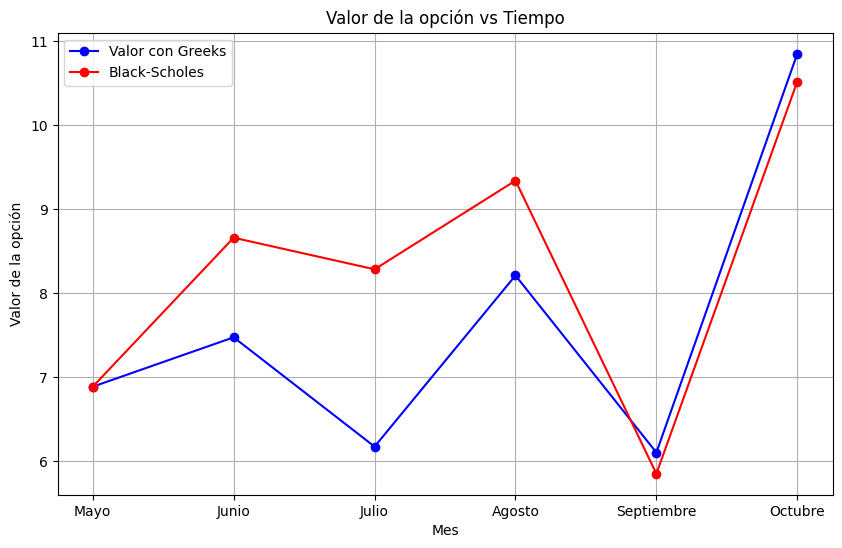

In [23]:
opcionvstiempo(df)

En la gráfica podemos ver que al principio los dos valores son muy parecidos, pero en junio, julio y agosto se empieza a notar mas la diferencia. En septiembre vuelven a estar bastante cerca y en octubre otra vez se separan un poco. Al final del periodo, el valor con Greeks es un poco mayor que el de Black-Scholes, con 10.85 vs 10.52. En general los Greeks siguen una tendencia parecida a Black-Scholes, pero al ser una aproximación con los datos iniciales no siempre dan el mismo valor.


---

1. ¿Los greeks iniciales describen con precisión toda la trayectoria?

   - No del todo, al principio si se parecen bastante pero conforme pasan los meses se empiezan a separar mas de Black-Scholes. Entonces sirven como una aproximación pero no son tan exactos para toda la trayectoria.

2. ¿En qué mes apareció el error más grande?

   - El error mas grande fue en julio, con un error de aproximadamente 2.11. En este mes fue donde mas se separaron los dos valores.

3. ¿Qué factor parece contribuir más al error?

   - Principalmente el cambio en la volatilidad, porque pasó de 20% a 30% en julio. También influye el cambio en el precio, pero la volatilidad tuvo bastante impacto en este caso.

4. ¿Por qué los Greeks funcionan mejor para movimientos pequeños que para movimientos grandes?

   - Porque los Greeks se calcularon usando las condiciones del inicio. Cuando los cambios son pequeños todavía estamos cerca de esas condiciones y la aproximación funciona bien. Pero si el precio o la volatilidad cambian mucho, los Greeks iniciales ya no representan tan bien el nuevo escenario.

5. Si la trayectoria fuera mucho más volátil, ¿esperarías errores menores? ¿por qué?

   - No, esperaría errores mas grandes. Si hay cambios muy fuertes en el precio y en la volatilidad, la opción se aleja mucho de las condiciones iniciales. Por eso la aproximación con los Greeks tendría mas dificultad para seguir el valor de Black-Scholes.

6. Concluye

   - En esta simulación podemos ver que los Greeks funcionan bien para aproximar el valor de la opción cuando los cambios no son tan grandes. Pero conforme cambia el precio y sobre todo la volatilidad, la diferencia con Black-Scholes aumenta. El error mas grande fue en julio, donde la volatilidad llegó a 30%. Entonces los Greeks son buenos para tener una estimación rápida, pero para cambios grandes es mejor usar un modelo que tome en cuenta las nuevas condiciones.


---